In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
import matplotlib.cm as cm
from scipy.stats import linregress
from matplotlib.patches import Patch

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_core_mean


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.189040,118.032741,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,1.122134,115.905401,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.055228,113.778061,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.871468,111.650721,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.945071,115.925719,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125221,2929,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,0.978558,61.312206,19.408106,1.110214,55.409919,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,0.752304,4.278123
125222,2929,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,0.972594,61.305207,19.388829,1.037331,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,1.165623,28.370419
125223,2929,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,0.949624,61.298208,19.369553,1.055789,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
125224,2929,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,0.937880,64.546558,19.604126,1.070344,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
num_profiles = len(df_eddies)-6*len(df_eddies.Eddy.unique())
print(f'Total No. of used profiles: {num_profiles}')
num_tilt_profiles = np.sum(~np.isnan(df_eddies.TiltDis))
print(f'Total No. of profiles tilt measured: {num_tilt_profiles}')
print(f'Tilt measuring success rate: {num_tilt_profiles/num_profiles*100:.2f}%')


Total No. of used profiles: 107652
Total No. of profiles tilt measured: 104459
Tilt measuring success rate: 97.03%


In [5]:
df_tilt_data_clean = df_tilt.dropna().copy()
percent_prof_TD_blw_20 = np.sum(df_tilt_data_clean.TiltDis <= 20) / num_tilt_profiles
print(f'% Profiles below 20km TD: {percent_prof_TD_blw_20*100:.2f}%')
print(f'Max TD {df_tilt_data_clean.TiltDis.max():.0f}')


% Profiles below 20km TD: 55.47%
Max TD 267


In [6]:
# Lifespan Day Index
day_idxs = []
for eddy in df_eddies.Eddy.unique():
    df = df_eddies[df_eddies.Eddy==eddy].copy()
    if len(df):
        day_idxs.extend(df.Day-df.Day.iloc[0])
df_eddies['Day_idx'] = day_idxs

# Dimensionless Time
df_eddies['norm_time'] = (
    df_eddies.groupby('Eddy')
    .cumcount() / (df_eddies.groupby('Eddy')['Eddy'].transform('size') - 1)
)


In [7]:
def panel(ax, xcol, xlabel, legend_key, xlim=None, split=None, reg_hi_override=None,
          scatter=False, xlim_flag=False, legend_flag=True, ncol=None, diff_flag=False,
          ylim=None, hline0=False, fit_flag=True, fit_all_flag=False, df_data=df_eddies):

    df_all = df_data.dropna(subset=[xcol])
    x = df_all[xcol].values
    x_min, x_max = x.min(), x.max()
    
    nbins = min(30, max(8, int(np.sqrt(len(x)))))
    bins = np.unique(np.quantile(x, np.linspace(0, 1, nbins + 1)))
    
    if len(bins) < 3:
        bins = np.linspace(x_min, x_max, 9)
    
    bin_centers = 0.5 * (bins[:-1] + bins[1:])


    for cyc in ['AE', 'CE']:
        dfm = df_data[df_data.Cyc == cyc].copy()

        if diff_flag:
            g_td = dfm.groupby('Eddy')['TiltDis']
            g_t  = dfm.groupby('Eddy')[xcol]
            
            dfm['tilt'] = (g_td.shift(-1) - g_td.shift(1)) / (g_t.shift(-1) - g_t.shift(1))

        else:
            dfm['tilt'] = dfm['TiltDis']

        dfm = dfm.dropna(subset=[xcol, 'tilt'])

        xval = dfm[xcol].values
        tilt = dfm['tilt'].values

        mask = (xval >= x_min) & (xval <= x_max)
        xval, tilt = xval[mask], tilt[mask]

        d = np.digitize(xval, bins)
        med = np.array([np.nanmedian(tilt[d == i]) if np.any(d == i) else np.nan for i in range(1, len(bins))])
        q25 = np.array([np.nanquantile(tilt[d == i], 0.25) if np.any(d == i) else np.nan for i in range(1, len(bins))])
        q75 = np.array([np.nanquantile(tilt[d == i], 0.75) if np.any(d == i) else np.nan for i in range(1, len(bins))])

        if scatter:
            ax.scatter(xval, tilt, s=1, alpha=0.08, color=styles[cyc]['fill'])

        m = ~np.isnan(med)
        ax.plot(bin_centers[m], med[m], lw=3, color=styles[cyc]['line'], alpha=.6)#, label=f'{cyc} median')
        ax.fill_between(bin_centers[m], q25[m], q75[m], color=styles[cyc]['fill'], alpha=0.10)#, label=f'{cyc} IQR')

        if fit_flag:
            if split is None:
                if fit_all_flag:
                    lo, hi = x_min, x_max
                else:
                    lo, hi = np.nanpercentile(xval, [10, 90])
                mask = (xval >= lo) & (xval <= hi)
                if mask.sum() > 2:
                    mreg, c, r, p, se = linregress(xval[mask], tilt[mask])
                    xf = np.linspace(lo, hi, 200)
                    ax.plot(
                        xf, mreg * xf + c, '--', lw=3, color=styles[cyc]['fill'],
                        label=fr'{cyc}: TD={mreg:.2f} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.2f}'
                    )
            else:
                lo, hi = np.nanpercentile(xval, [10, 90])
                hi2 = reg_hi_override if reg_hi_override is not None else hi
    
                for l, (a, b) in enumerate(zip([lo, split], [split, hi2])):
                    mask = (xval >= a) & (xval <= b)
                    if mask.sum() > 2:
                        mreg, c, r, p, se = linregress(xval[mask], tilt[mask])
                        xf = np.linspace(a, b, 200)
                        ax.plot(
                            xf, mreg * xf + c,
                            ':' if l == 0 else '--',
                            lw=3,
                            color=styles[cyc]['fill'],
                            label=fr'{cyc}: TD={mreg:.2e} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.2f}'
                        )

    if ylim is not None:
        ax.set_ylim(*ylim)

    if xlim is None:
        ax.set_xlim(*np.nanpercentile(df_data[xcol], [10, 90]))
    else:
        ax.set_xlim(*xlim)

    if xlim_flag:
        ax.set_xlim(bin_centers.min(), bin_centers.max())

    if hline0:
        ax.axhline(0, lw=0.5, ls='--', color='k', zorder=-1)

    if legend_flag:
        ax.legend(loc='upper left', ncol=ncol if ncol is not None else 2)

    ax.set_xlabel(xlabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


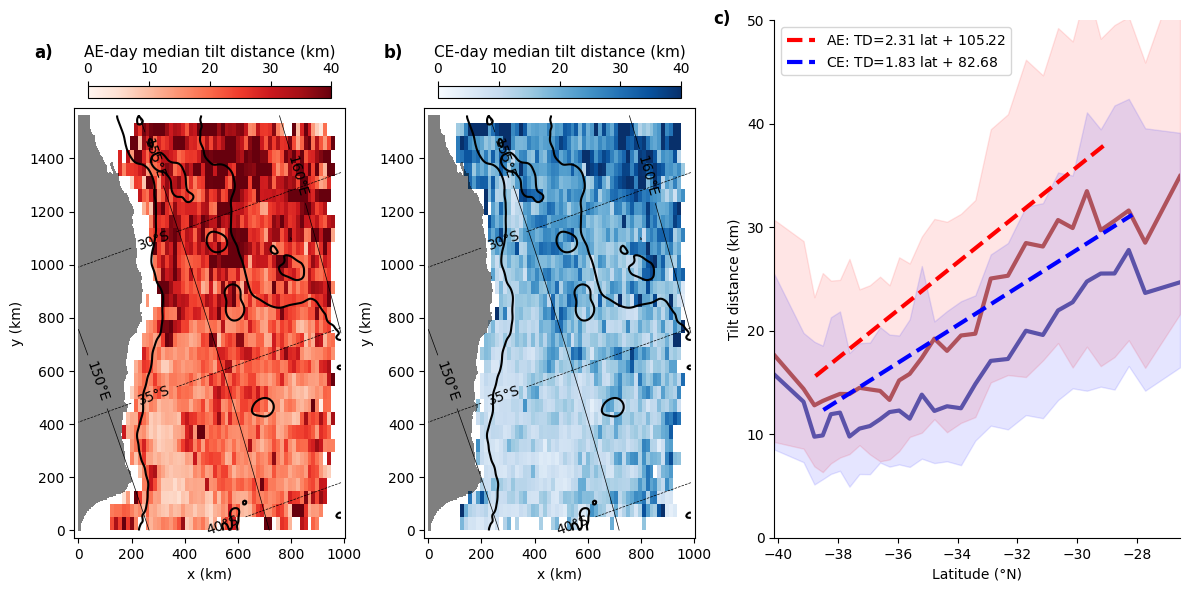

In [8]:
def _nice_step(h, base):
    s = h / base
    for k in [1, 2, 2.5, 5, 10]:
        if s <= k:
            return k * base
    return np.ceil(s) * base

def _grid_step(G):
    gx = np.diff(np.sort(np.unique(G.ravel())))
    return np.nanmedian(gx[gx > 0])

def _bin_edges_fd(x, grid, scale=1.0, rule='fd'):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    n = len(x)

    if n < 2:
        lo, hi = np.nanmin(x), np.nanmax(x)
        return np.array([lo, hi])

    iqr = np.subtract(*np.percentile(x, [75, 25]))
    std = np.std(x, ddof=1)

    if rule.lower() == 'fd':
        bw = 2 * (iqr if iqr > 0 else 1.349 * std) / (n ** (1 / 3))
    else:
        bw = 3.5 * std / (n ** (1 / 3))

    if not np.isfinite(bw) or bw <= 0:
        rng = np.ptp(x)
        bw = rng / max(10, np.sqrt(n))

    base = _grid_step(grid)
    bw = _nice_step(scale * bw, base)

    lo = np.floor(np.nanmin(x) / bw) * bw
    hi = np.ceil(np.nanmax(x) / bw) * bw
    return np.arange(lo, hi + bw, bw)

def binned_median(x, y, v, xbins, ybins):
    ix = np.digitize(x, xbins) - 1
    iy = np.digitize(y, ybins) - 1
    nx, ny = len(xbins) - 1, len(ybins) - 1
    ok = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny) & np.isfinite(v)

    ix, iy, v = ix[ok], iy[ok], v[ok]
    flat = iy * nx + ix

    hmed = np.full(nx * ny, np.nan)
    for k in np.unique(flat):
        hmed[k] = np.nanmedian(v[flat == k])

    return hmed.reshape(ny, nx)

xbins = _bin_edges_fd(df_eddies.xc.values, X_grid, scale=1.0, rule='fd')
ybins = _bin_edges_fd(df_eddies.yc.values, Y_grid, scale=1.0, rule='fd')

vmin, vmax = 0, 40
levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]

from matplotlib.colors import Normalize
norm = Normalize(vmin=vmin, vmax=vmax)
cmaps = {"AE-day": "Reds", "CE-day": "Blues"}

styles = {
    'AE': {'line': 'darkred', 'fill': 'red'},
    'CE': {'line': 'navy',    'fill': 'blue'}
}

fig, axs = plt.subplots(
    1, 3, figsize=(12, 6),
    gridspec_kw={'width_ratios': [1, 1, 1.5]},
    sharey=False
)

# --- first two map panels ---
p = 0
tag = ['a)', 'b)']
for ax, cyc in zip(axs[:2], ['AE-day', 'CE-day']):
    df = df_eddies[df_eddies.Cyc == cyc[:2]].copy()
    df = df.sort_values('TiltDis', kind='mergesort', ignore_index=True)

    ax.contour(X_grid, Y_grid, h, levels=[4000], colors='k')

    H = binned_median(df.xc.values, df.yc.values, df.TiltDis.values, xbins, ybins)
    m = ax.pcolormesh(
        xbins, ybins, H,
        cmap=cmaps[cyc], norm=norm,
        shading='auto', rasterized=True
    )

    cb = fig.colorbar(m, ax=ax, location='top', shrink=0.9, pad=0.02)
    cb.set_label(f'{cyc} median tilt distance (km)', fontsize=11)
    cb.set_ticks(np.linspace(vmin, vmax, 5))

    ax.contourf(
        X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
        levels=[0.5, 1.5], colors=['k'], alpha=.5
    )

    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat, colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{-v:.0f}°S", inline=True, colors='k')

    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon, colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

    ax.axis('equal')
    ax.set_xlim(X_grid.min(), X_grid.max())
    ax.set_ylim(Y_grid.min(), Y_grid.max())
    ax.set_xlabel('x (km)')
    # ax.set_title(cyc, fontsize=12)

    ax.set_ylabel('y (km)')

    ax.text(-0.15, 1.15, tag[p], transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
    p += 1

# --- third latitude panel ---
panel(
    ax=axs[2],
    xcol='lat',
    xlabel=r'Latitude (°N)',
    legend_key=r'lat',
    xlim=(lat_rho.min(), lat_rho.max()),
    split=None,
    reg_hi_override=None,
    scatter=False,
    xlim_flag=True,
    ncol=1,
    ylim=(0,None)
)
axs[2].set_ylim(0, 50)
axs[2].set_ylabel('Tilt distance (km)')#, fontsize=12)
axs[2].text(-0.15, 1.02, 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


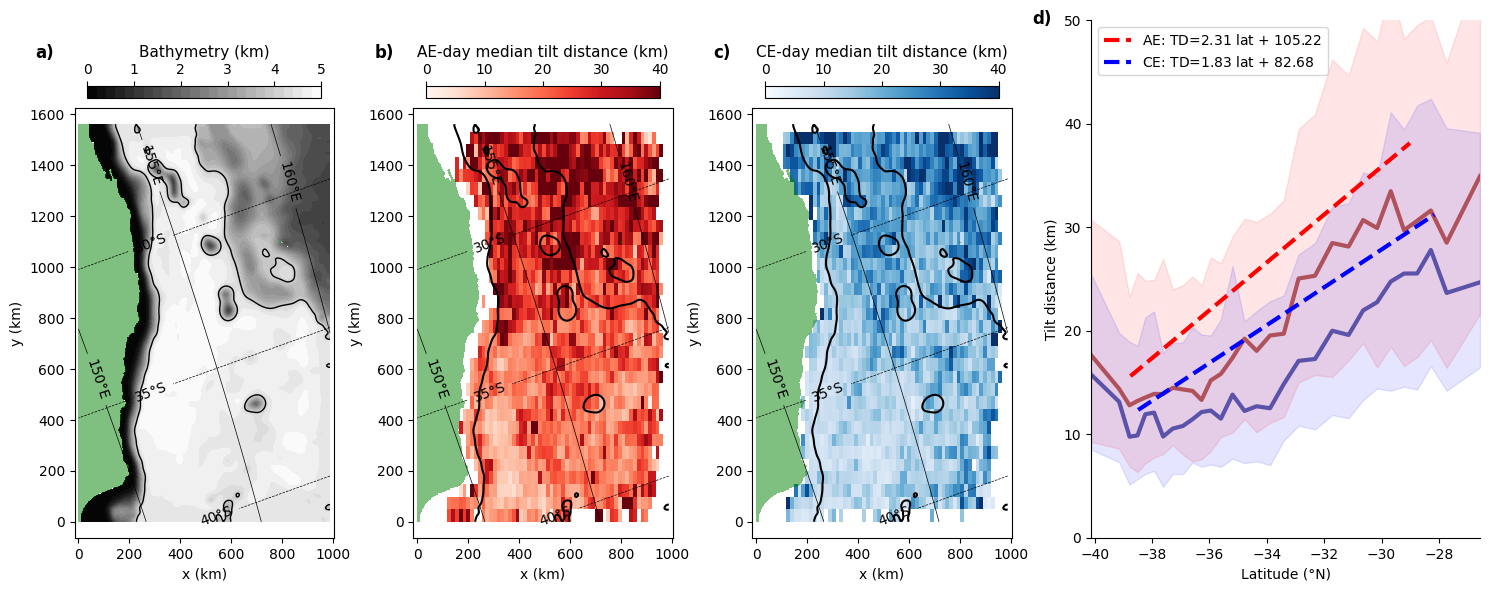

In [33]:
xbins = _bin_edges_fd(df_eddies.xc.values, X_grid, scale=1.0, rule='fd')
ybins = _bin_edges_fd(df_eddies.yc.values, Y_grid, scale=1.0, rule='fd')

vmin, vmax = 0, 40
levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]

from matplotlib.colors import Normalize
norm = Normalize(vmin=vmin, vmax=vmax)
cmaps = {"AE-day": "Reds", "CE-day": "Blues"}

fig, axs = plt.subplots(
    1, 4,
    figsize=(15, 6),
    gridspec_kw={'width_ratios': [1, 1, 1, 1.5]},
    sharey=False
)

# --- far-left bathymetry map ---
ax = axs[0]

m0 = ax.contourf(
    X_grid, Y_grid, np.where(mask_rho, h, np.nan) / 1e3,
    levels=30,
    cmap='grey'
    # extend='both',
)

cb0 = fig.colorbar(m0, ax=ax, location='top', shrink=0.9, pad=0.02)
cb0.set_label('Bathymetry (km)', fontsize=11)
cb0.set_ticks(np.arange(0, np.ceil(np.nanmax(h/1e3)) + 1, 1))

ax.contour(X_grid, Y_grid, h, levels=[4e3], colors='k', linewidths=1)

ax.contourf(
    X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
    levels=[0.5, 1.5], colors=['g'], alpha=.5
)

c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat, colors='k', linewidths=.5)
ax.clabel(c1, fmt=lambda v: f"{-v:.0f}°S", inline=True, colors='k')

c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon, colors='k', linewidths=.5)
ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

ax.axis('equal')
ax.set_xlim(X_grid.min(), X_grid.max())
ax.set_ylim(Y_grid.min(), Y_grid.max())
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.text(-0.15, 1.15, 'a)', transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left')


# --- AE / CE map panels ---
tags = ['b)', 'c)']

for p, (ax, cyc) in enumerate(zip(axs[1:3], ['AE-day', 'CE-day'])):

    df = df_eddies[df_eddies.Cyc == cyc[:2]].copy()
    df = df.sort_values('TiltDis', kind='mergesort', ignore_index=True)

    ax.contour(X_grid, Y_grid, h, levels=[4000], colors='k')

    H = binned_median(df.xc.values, df.yc.values, df.TiltDis.values, xbins, ybins)

    m = ax.pcolormesh(
        xbins, ybins, H,
        cmap=cmaps[cyc],
        norm=norm,
        shading='auto',
        rasterized=True
    )

    cb = fig.colorbar(m, ax=ax, location='top', shrink=0.9, pad=0.02)
    cb.set_label(f'{cyc} median tilt distance (km)', fontsize=11)
    cb.set_ticks(np.linspace(vmin, vmax, 5))

    ax.contourf(
        X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
        levels=[0.5, 1.5], colors=['g'], alpha=.5
    )

    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat, colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{-v:.0f}°S", inline=True, colors='k')

    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon, colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

    ax.axis('equal')
    ax.set_xlim(X_grid.min(), X_grid.max())
    ax.set_ylim(Y_grid.min(), Y_grid.max())
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')

    ax.text(-0.15, 1.15, tags[p], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')


# --- latitude panel ---
panel(
    ax=axs[3],
    xcol='lat',
    xlabel=r'Latitude (°N)',
    legend_key=r'lat',
    xlim=(lat_rho.min(), lat_rho.max()),
    split=None,
    reg_hi_override=None,
    scatter=False,
    xlim_flag=True,
    ncol=1,
    ylim=(0, None)
)

axs[3].set_ylim(0, 50)
axs[3].set_ylabel('Tilt distance (km)')
axs[3].text(-0.15, 1.02, 'd)', transform=axs[3].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()


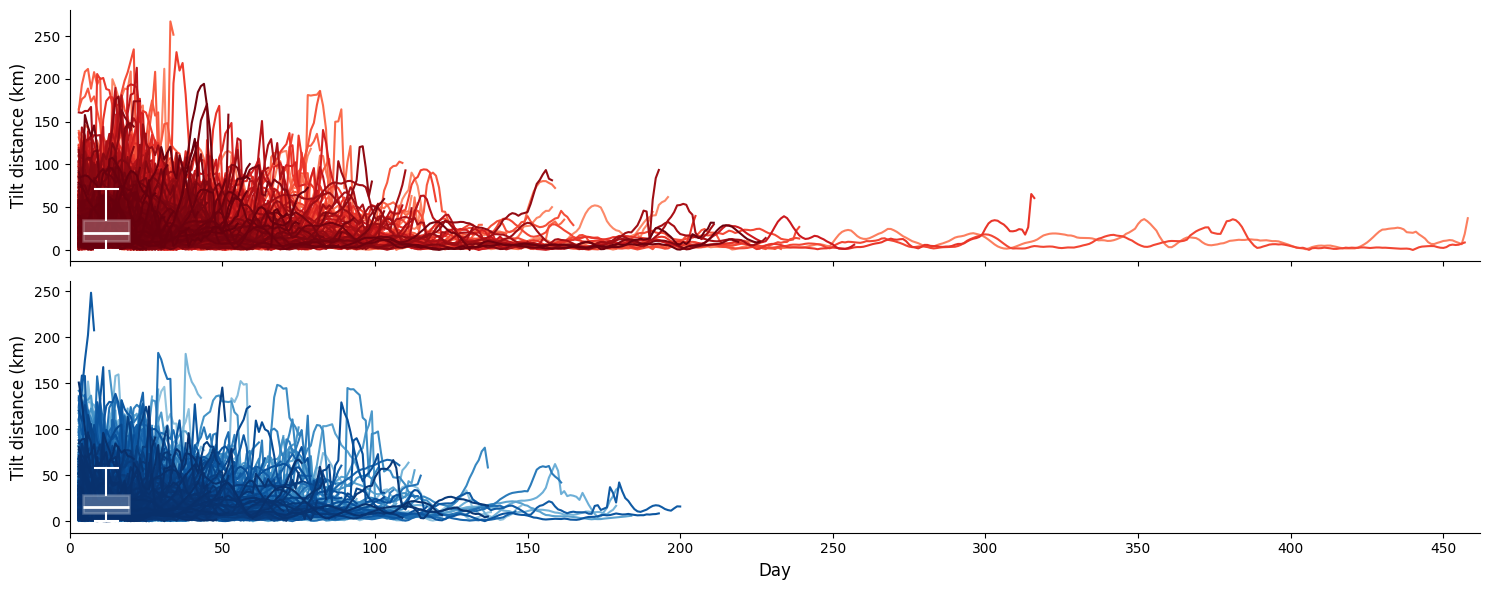

In [10]:
df_data = df_eddies.copy()

ae = df_data[df_data.Cyc == 'AE'].Eddy.unique()
ce = df_data[df_data.Cyc == 'CE'].Eddy.unique()

colors_ae = cm.Reds(np.linspace(0.4, 1, len(ae)))
colors_ce = cm.Blues(np.linspace(0.4, 1, len(ce)))

fig, axs = plt.subplots(2, 1, figsize=(15,6), sharex=True)

ae_idx, ce_idx = 0, 0
max_len_ae, max_len_ce = 0, 0
tilt_ae_all, tilt_ce_all = [], []

for eddy in df_data.Eddy.unique():
    df = df_data[df_data.Eddy == eddy]
    tilt = df.TiltDis.dropna().values
    
    if df.Cyc.iloc[0] == 'AE':
        x = np.arange(len(df))
        axs[0].plot(x, df.TiltDis, color=colors_ae[ae_idx])
        max_len_ae = max(max_len_ae, len(df))
        tilt_ae_all.extend(tilt)
        ae_idx += 1
    else:
        x = np.arange(len(df))
        axs[1].plot(x, df.TiltDis, color=colors_ce[ce_idx])
        max_len_ce = max(max_len_ce, len(df))
        tilt_ce_all.extend(tilt)
        ce_idx += 1

# Add boxplots at end
box_pos_ae = 12 #max_len_ae + 2
box_pos_ce = 12 #max_len_ce + 2

bp1 = axs[0].boxplot(
    tilt_ae_all,
    positions=[box_pos_ae],
    widths=15,
    patch_artist=True,
    showfliers=False
)

bp2 = axs[1].boxplot(
    tilt_ce_all,
    positions=[box_pos_ce],
    widths=15,
    patch_artist=True,
    showfliers=False
)

# --- Apply consistent AE/CE theme ---
for b, bp in enumerate([bp1, bp2]):
    c = 'w' if b == 0 else 'w'
    # Boxes
    for box in bp['boxes']:
        box.set(facecolor=c, edgecolor=c, alpha=0.25, linewidth=1.8)
    # Medians
    for median in bp['medians']:
        median.set(color=c, linewidth=2)
    # Whiskers
    for whisker in bp['whiskers']:
        whisker.set(color=c, linewidth=1.5)
    # Caps
    for cap in bp['caps']:
        cap.set(color=c, linewidth=1.5)

# Set consistent x limits first (important)
max_len = max(max_len_ae, max_len_ce)
axs[0].set_xlim(0, max_len)
axs[1].set_xlim(0, max_len)

# Define ticks
xticks = np.arange(0, 451, 50)

# Apply only to bottom axis (shared x)
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks)

# Styling
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Tilt distance (km)', fontsize=12)

axs[1].set_xlabel('Day', fontsize=12)
axs[1].tick_params(labelbottom=True)

plt.tight_layout()


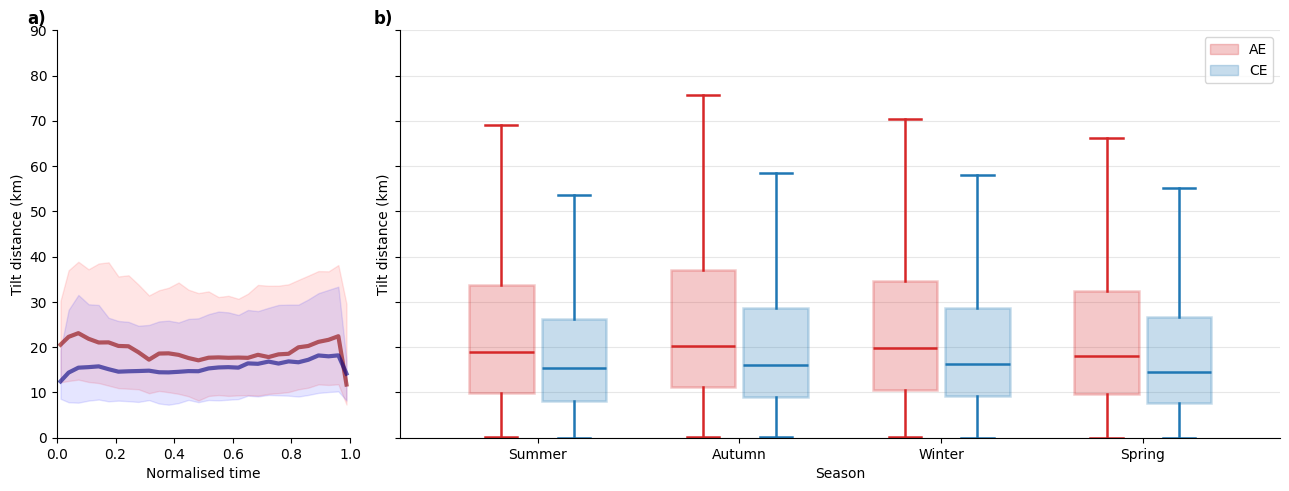

In [11]:
# -----------------------------
# 1) Only consider eddies with full interior tilt measurements
# -----------------------------
def valid_eddy(g):
    if len(g) <= 6:
        return False
    core = g.iloc[3:-3]
    return core['TiltDis'].notna().all()

df_full = df_eddies.groupby('Eddy').filter(valid_eddy)

# split AE / CE from the filtered dataframe
df_AE_full = df_full[df_full['Cyc'] == 'AE'].copy()
df_CE_full = df_full[df_full['Cyc'] == 'CE'].copy()

# -----------------------------
# 2) Seasonal prep
# -----------------------------
DATE_COL = 'date' if 'date' in df_full.columns else 'Date'

season_map = {
    12: 'Summer', 1: 'Summer', 2: 'Summer',
    3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
    6: 'Winter', 7: 'Winter', 8: 'Winter',
    9: 'Spring', 10: 'Spring', 11: 'Spring'
}
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']

def prep(df, kind):
    out = df[[DATE_COL, 'TiltDis']].copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL])
    out['Season'] = out[DATE_COL].dt.month.map(season_map)
    out['Season'] = pd.Categorical(out['Season'], categories=season_order, ordered=True)
    out['Type'] = kind
    return out

d = pd.concat([prep(df_AE_full, 'AE'), prep(df_CE_full, 'CE')], ignore_index=True)

x = np.arange(len(season_order))
offset = 0.18
pos_AE = x - offset
pos_CE = x + offset

data_AE = [d[(d['Type'] == 'AE') & (d['Season'] == s)]['TiltDis'].dropna().to_numpy() for s in season_order]
data_CE = [d[(d['Type'] == 'CE') & (d['Season'] == s)]['TiltDis'].dropna().to_numpy() for s in season_order]

# -----------------------------
# 3) Combined 1x2 figure
# -----------------------------
fig, axs = plt.subplots(
    1, 2,
    figsize=(13, 5),
    gridspec_kw={'width_ratios': [1, 3]},
    sharey=True
)

# ---- Left: original first panel
panel(
    ax=axs[0],
    xcol='norm_time',
    xlabel='Normalised time',
    legend_key=r'$x$',
    xlim=(0, 1),
    split=None,
    reg_hi_override=None,
    scatter=False,
    xlim_flag=True,
    ncol=2,
    diff_flag=False,
    ylim=(0, None),
    fit_flag=False,
    df_data=df_full,
    legend_flag=False
)

axs[0].set_ylabel('Tilt distance (km)')
axs[0].set_xlim(0, 1)

# ---- Right: seasonal boxplot
bp_AE = axs[1].boxplot(data_AE, positions=pos_AE, widths=0.32, patch_artist=True, showfliers=False)
bp_CE = axs[1].boxplot(data_CE, positions=pos_CE, widths=0.32, patch_artist=True, showfliers=False)

def style_bp(bp, face, edge):
    for b in bp['boxes']:
        b.set(facecolor=face, edgecolor=edge, alpha=0.25, linewidth=1.8)
    for k in ['whiskers', 'caps', 'medians']:
        for item in bp[k]:
            item.set(color=edge, linewidth=1.8)

style_bp(bp_AE, face='tab:red', edge='tab:red')
style_bp(bp_CE, face='tab:blue', edge='tab:blue')

axs[1].set_xticks(x)
axs[1].set_xticklabels(season_order)
axs[1].set_xlabel('Season')
axs[1].set_ylabel('Tilt distance (km)')
axs[1].set_ylim(0, 90)
axs[1].grid(True, axis='y', alpha=0.3)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[1].legend(handles=[
    Patch(facecolor='tab:red', edgecolor='tab:red', alpha=0.25, label='AE'),
    Patch(facecolor='tab:blue', edgecolor='tab:blue', alpha=0.25, label='CE')
])

# panel labels
axs[0].text(-0.1, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].text(-0.03, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
plt.tight_layout()
plt.show()


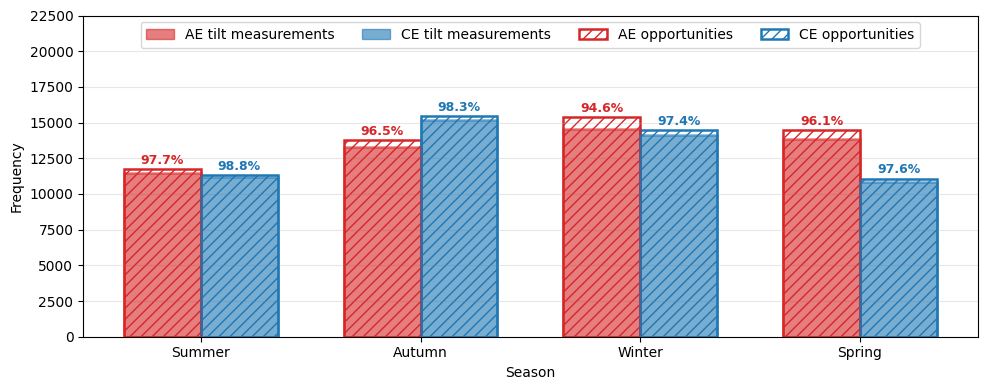

In [12]:
df_AE = df_eddies[df_eddies.Cyc=='AE'].copy()
df_CE = df_eddies[df_eddies.Cyc=='CE'].copy()

DATE_COL = 'Date'

season_map = {
    12:'Summer', 1:'Summer', 2:'Summer',
    3:'Autumn', 4:'Autumn', 5:'Autumn',
    6:'Winter', 7:'Winter', 8:'Winter',
    9:'Spring',10:'Spring',11:'Spring'
}
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']

def prep(df, kind):
    out = df[[DATE_COL, 'TiltDis', 'Day_idx', 'Age']].copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL])
    out['Season'] = out[DATE_COL].dt.month.map(season_map)
    out['Season'] = pd.Categorical(out['Season'], categories=season_order, ordered=True)
    out['Type'] = kind
    out['Measurable'] = (out['Day_idx'] > 2) & (np.abs(out['Day_idx'] - (out['Age'] - 1)) > 2)
    return out

d = pd.concat([prep(df_AE, 'AE'), prep(df_CE, 'CE')], ignore_index=True)

opportunity_counts = (
    d[d['Measurable']]
    .groupby(['Season', 'Type'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(season_order, fill_value=0)
)

tilt_counts = (
    d[d['Measurable'] & d['TiltDis'].notna()]
    .groupby(['Season', 'Type'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(season_order, fill_value=0)
)

success = (tilt_counts / opportunity_counts.replace(0, np.nan) * 100).fillna(0)

x = np.arange(len(season_order))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(x - w/2, opportunity_counts['AE'], w, facecolor='none', edgecolor='tab:red',
       linewidth=1.8, hatch='///', zorder=1)
ax.bar(x + w/2, opportunity_counts['CE'], w, facecolor='none', edgecolor='tab:blue',
       linewidth=1.8, hatch='///', zorder=1)

bars_AE = ax.bar(x - w/2, tilt_counts['AE'], w, color='tab:red', alpha=0.6,
                 edgecolor='tab:red', linewidth=1.8, zorder=2)
bars_CE = ax.bar(x + w/2, tilt_counts['CE'], w, color='tab:blue', alpha=0.6,
                 edgecolor='tab:blue', linewidth=1.8, zorder=2)

ymax = np.nanmax(opportunity_counts.to_numpy())
pad = 0.01 * ymax

for i, s in enumerate(season_order):
    yA = opportunity_counts.loc[s, 'AE']
    yC = opportunity_counts.loc[s, 'CE']
    ax.text(x[i] - w/2, yA + pad, f"{success.loc[s, 'AE']:.1f}%", ha='center', va='bottom',
            color='tab:red', fontsize=9, fontweight='bold')
    ax.text(x[i] + w/2, yC + pad, f"{success.loc[s, 'CE']:.1f}%", ha='center', va='bottom',
            color='tab:blue', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(season_order)
ax.set_xlabel('Season')
ax.set_ylabel('Frequency')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 22500)

ax.legend(loc='upper center', ncol=4, handles=[
    Patch(facecolor='tab:red', edgecolor='tab:red', alpha=0.6, label='AE tilt measurements'),
    Patch(facecolor='tab:blue', edgecolor='tab:blue', alpha=0.6, label='CE tilt measurements'),
    Patch(facecolor='none', edgecolor='tab:red', hatch='///', linewidth=1.8, label='AE opportunities'),
    Patch(facecolor='none', edgecolor='tab:blue', hatch='///', linewidth=1.8, label='CE opportunities'),
])

plt.tight_layout()
plt.show()


In [13]:
with open('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl', 'rb') as f:
    dic_vert = pickle.load(f)


In [14]:
kmday_to_ms = 1000 / 86400

# --- top-centre displacements + propagation speed ---
df_eddies['dx_top'] = df_eddies.groupby('Eddy')['xc'].diff()
df_eddies['dy_top'] = df_eddies.groupby('Eddy')['yc'].diff()
df_eddies['EddyProp'] = np.hypot(df_eddies['dx_top'], df_eddies['dy_top']) * kmday_to_ms

# --- bottom-centre positions (single pass) ---
df_idx = df_eddies.set_index(['Eddy', 'Day'])

x_btm, y_btm = [], []
for eddy, dic in dic_vert.items():
    eddy_id = int(eddy[4:])  # "Eddy####" -> ####
    for day, df in dic.items():
        day_id = int(day[3:])  # "Day##" -> ##
        if len(df):
            d = df[df.Depth.abs() < 1000]
            row = (d.iloc[-1] if len(d) else df.iloc[-1])
        else:
            row = df_idx.loc[(eddy_id, day_id)]
        x_btm.append(row.xc)
        y_btm.append(row.yc)

df_eddies['x_btm'] = x_btm
df_eddies['y_btm'] = y_btm

# --- bottom-centre displacements + propagation speed ---
df_eddies['dx_btm'] = df_eddies.groupby('Eddy')['x_btm'].diff()
df_eddies['dy_btm'] = df_eddies.groupby('Eddy')['y_btm'].diff()
df_eddies['btm_prop'] = np.hypot(df_eddies['dx_btm'], df_eddies['dy_btm']) * kmday_to_ms

# --- separation and separation rate ---
df_eddies['sep_km'] = np.hypot(df_eddies['x_btm'] - df_eddies['xc'],
                               df_eddies['y_btm'] - df_eddies['yc'])
df_eddies['sep_rate_ms'] = df_eddies.groupby('Eddy')['sep_km'].diff() * kmday_to_ms

# --- optional: vector difference between top and bottom (m/s) ---
df_eddies['top_btm_diff'] = np.hypot(df_eddies['dx_btm'] - df_eddies['dx_top'],
                                     df_eddies['dy_btm'] - df_eddies['dy_top']) * kmday_to_ms


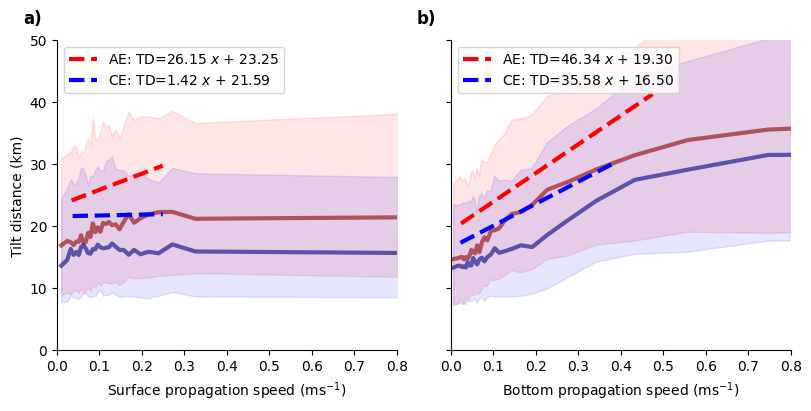

In [15]:
# ---- latitude plot using the same structure ----
fig, axs = plt.subplots(1,2, figsize=(8, 4), constrained_layout=True, sharey=True) 
styles = {
    'AE': {'line': 'darkred', 'fill': 'red'},
    'CE': {'line': 'navy',    'fill': 'blue'}
}

panel(
    ax=axs[0],
    xcol='EddyProp',
    xlabel=r'Surface propagation speed (ms$^{-1}$)',
    legend_key=r'$x$',
    # xlim=(0, .4),
    split=None,
    reg_hi_override=None,
    scatter=False,
    xlim_flag=True,
    legend_flag=True,
    ncol=1,
    df_data=df_eddies
)
axs[0].set_ylabel('Tilt distance (km)')#, fontsize=12)
axs[0].set_xlim(0, .8)
axs[0].text(-0.1, 1.1, 'a)', transform=axs[0].transAxes,
               fontsize=12, fontweight='bold', va='top', ha='left')

panel(
    ax=axs[1],
    xcol='btm_prop',
    xlabel=r'Bottom propagation speed (ms$^{-1}$)',
    legend_key=r'$x$',
    # xlim=(lat_rho.min(), lat_rho.max()),
    split=None,
    reg_hi_override=None,
    scatter=False,
    xlim_flag=True,
    legend_flag=True,
    ncol=1,
    df_data=df_eddies
)
axs[1].set_xlim(0, .8)
axs[1].text(-0.1, 1.1, 'b)', transform=axs[1].transAxes,
               fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].set_ylim(0, 50)
plt.show()

